# Laboratorio 8 - 2

## Etapa 4: Efecto del intercambio de repetidas

Se estudia un mecanismo de intercambio donde cada `K` estampas repetidas se canjean por 1 estampa nueva que todavía falte en el álbum. El canje se aplica después de abrir cada sobre.

Parámetros usados:

- Álbum reducido: `N = 100` estampas.
- Estampas por sobre: `S = 7`.
- Simulaciones por configuración: `R = 10000`.
- Semilla: `2026`.
- Valores principales: `K = 1, 2, 5, 10`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEMILLA = 2026
N = 100
S = 7
R = 10_000
PRECIO_SOBRE = 9.50

K_VALORES = [1, 2, 5, 10]
M_VALORES = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])


## Funciones de simulación

En vez de guardar explícitamente el conjunto de estampas, se guarda cuántas estampas distintas tiene el álbum. Si en un momento hay `c` estampas coleccionadas, entonces al abrir un sobre de 7 estampas distintas el número de estampas nuevas sigue una distribución hipergeométrica.

Este método es equivalente a elegir estampas uniformemente, porque todas las estampas son simétricas: para el futuro solo importa cuántas faltan, no cuáles son. Cuando se realiza un canje, se reduce en 1 el número de faltantes, igual que elegir una estampa que realmente falte.


In [2]:
def simular_hasta_completar_lote(n, s, r, k, rng):
    """Simula r álbumes hasta completarlos. k=None representa no usar intercambio."""
    coleccionadas = np.zeros(r, dtype=np.int16)
    repetidas = np.zeros(r, dtype=np.int16)
    sobres = np.zeros(r, dtype=np.int16)

    activos = coleccionadas < n
    while np.any(activos):
        idx = np.flatnonzero(activos)

        nuevas = rng.hypergeometric(n - coleccionadas[idx], coleccionadas[idx], s)
        duplicadas = s - nuevas
        coleccionadas[idx] += nuevas.astype(np.int16)

        if k is not None:
            repetidas[idx] += duplicadas.astype(np.int16)
            canjes = np.minimum(repetidas[idx] // k, n - coleccionadas[idx])
            coleccionadas[idx] += canjes.astype(np.int16)
            repetidas[idx] -= (canjes * k).astype(np.int16)

        sobres[idx] += 1
        activos = coleccionadas < n

    return sobres


def simular_probabilidades_m_lote(n, s, r, k, m_valores, rng):
    """Estima P(completar | M sobres) para varios M. k=None representa no intercambio."""
    coleccionadas = np.zeros(r, dtype=np.int16)
    repetidas = np.zeros(r, dtype=np.int16)
    probabilidades = []
    checkpoints = set(m_valores.tolist())

    for m in range(1, int(m_valores.max()) + 1):
        activos = coleccionadas < n
        idx = np.flatnonzero(activos)

        if len(idx) > 0:
            nuevas = rng.hypergeometric(n - coleccionadas[idx], coleccionadas[idx], s)
            duplicadas = s - nuevas
            coleccionadas[idx] += nuevas.astype(np.int16)

            if k is not None:
                repetidas[idx] += duplicadas.astype(np.int16)
                canjes = np.minimum(repetidas[idx] // k, n - coleccionadas[idx])
                coleccionadas[idx] += canjes.astype(np.int16)
                repetidas[idx] -= (canjes * k).astype(np.int16)

        if m in checkpoints:
            probabilidades.append(np.mean(coleccionadas >= n))

    return np.array(probabilidades)


def primer_m_que_alcanza(m_valores, probabilidades, umbral):
    indices = np.flatnonzero(probabilidades >= umbral)
    return None if len(indices) == 0 else int(m_valores[indices[0]])


def formato_m(valor):
    return "No alcanza" if valor is None else str(valor)


## Parte A: Sobres necesarios hasta completar

Se simula el proceso hasta completar el álbum para el caso sin intercambio y para cada valor de `K`. La reducción porcentual se calcula respecto a la media del caso sin intercambio.


In [4]:
rng_a = np.random.default_rng(SEMILLA)

resultados_a = {"Sin intercambio": simular_hasta_completar_lote(N, S, R, None, rng_a)}
for k in K_VALORES:
    resultados_a[f"K={k}"] = simular_hasta_completar_lote(N, S, R, k, rng_a)

media_sin_intercambio = resultados_a["Sin intercambio"].mean()

resumen_a = []
for etiqueta, datos in resultados_a.items():
    media = datos.mean()
    std = datos.std(ddof=1)
    reduccion = (media_sin_intercambio - media) / media_sin_intercambio * 100
    resumen_a.append((etiqueta, media, std, reduccion))

encabezado = f"{'Caso':<18} | {'Media':>8} | {'Desv. est.':>10} | {'Reducción':>10}"
print(encabezado)
print("-" * len(encabezado))
for etiqueta, media, std, reduccion in resumen_a:
    print(f"{etiqueta:<18} | {media:8.3f} | {std:10.3f} | {reduccion:9.2f}%")


Caso               |    Media | Desv. est. |  Reducción
-------------------------------------------------------
Sin intercambio    |   72.472 |     17.546 |      0.00%
K=1                |   15.000 |      0.000 |     79.30%
K=2                |   19.867 |      0.541 |     72.59%
K=5                |   28.096 |      1.423 |     61.23%
K=10               |   35.157 |      2.477 |     51.49%


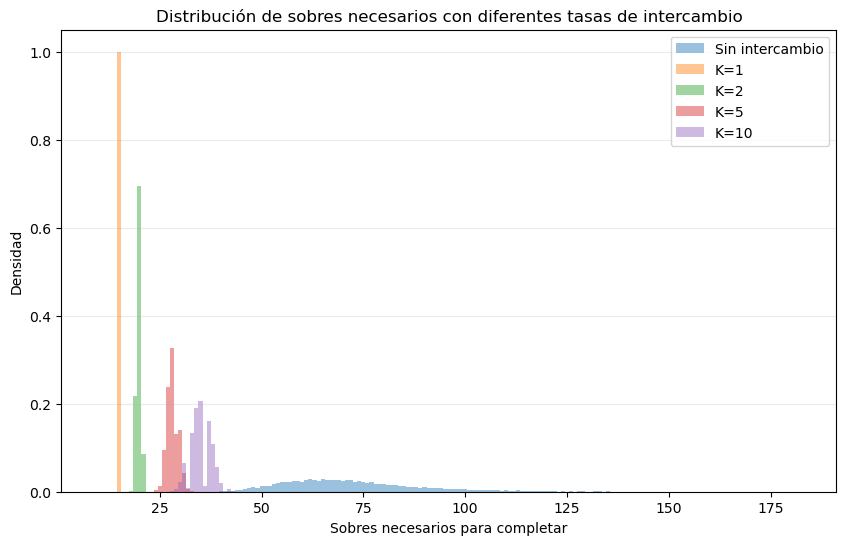

In [5]:
plt.figure(figsize=(10, 6))
max_sobres = max(int(datos.max()) for datos in resultados_a.values())
bins = np.arange(10, max_sobres + 2) - 0.5

for etiqueta, datos in resultados_a.items():
    plt.hist(datos, bins=bins, alpha=0.45, density=True, label=etiqueta)

plt.xlabel("Sobres necesarios para completar")
plt.ylabel("Densidad")
plt.title("Distribución de sobres necesarios con diferentes tasas de intercambio")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


Resultados de la Parte A con semilla 2026:

| Caso | Media | Desv. est. | Reducción vs. sin intercambio |
|---|---:|---:|---:|
| Sin intercambio | 72.472 | 17.546 | 0.00 % |
| K=1 | 15.000 | 0.000 | 79.30 % |
| K=2 | 19.867 | 0.541 | 72.59 % |
| K=5 | 28.096 | 1.423 | 61.23 % |
| K=10 | 35.157 | 2.477 | 51.49 % |


## Parte B: Probabilidad de éxito con M sobres

Ahora se compran exactamente `M` sobres y se estima la proporción de simulaciones donde el álbum queda completo. Se incluye la curva de referencia sin intercambio.


In [6]:
rng_b = np.random.default_rng(SEMILLA)

probabilidades_b = {
    "Sin intercambio": simular_probabilidades_m_lote(N, S, R, None, M_VALORES, rng_b)
}
for k in K_VALORES:
    probabilidades_b[f"K={k}"] = simular_probabilidades_m_lote(N, S, R, k, M_VALORES, rng_b)

encabezado = "M".rjust(5) + " | " + " | ".join(etiqueta.rjust(16) for etiqueta in probabilidades_b)
print(encabezado)
print("-" * len(encabezado))
for i, m in enumerate(M_VALORES):
    fila = f"{m:5d}"
    for etiqueta in probabilidades_b:
        fila += f" | {probabilidades_b[etiqueta][i]:16.4f}"
    print(fila)


    M |  Sin intercambio |              K=1 |              K=2 |              K=5 |             K=10
----------------------------------------------------------------------------------------------------
   20 |           0.0000 |           1.0000 |           0.9100 |           0.0000 |           0.0000
   25 |           0.0000 |           1.0000 |           1.0000 |           0.0189 |           0.0000
   30 |           0.0000 |           1.0000 |           1.0000 |           0.9515 |           0.0304
   35 |           0.0001 |           1.0000 |           1.0000 |           1.0000 |           0.6282
   40 |           0.0022 |           1.0000 |           1.0000 |           1.0000 |           0.9921
   45 |           0.0142 |           1.0000 |           1.0000 |           1.0000 |           1.0000
   50 |           0.0587 |           1.0000 |           1.0000 |           1.0000 |           1.0000
   55 |           0.1422 |           1.0000 |           1.0000 |           1.0000 |        

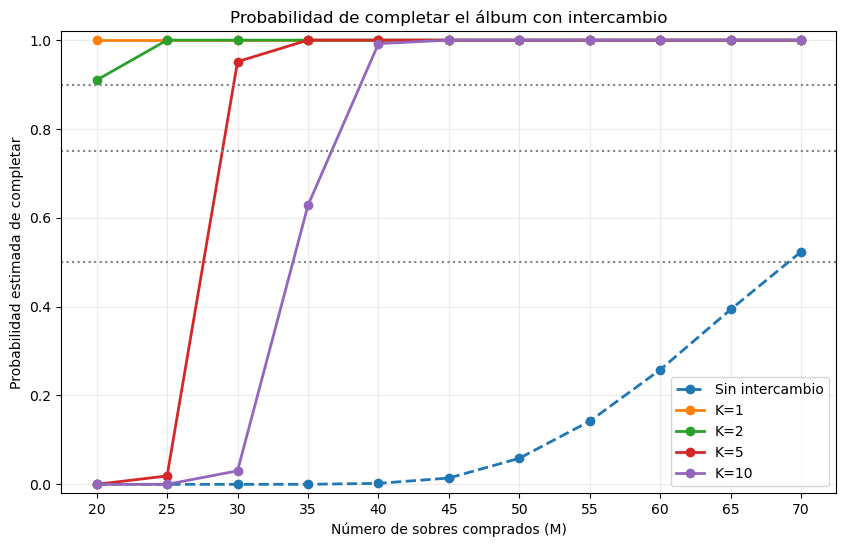

In [7]:
plt.figure(figsize=(10, 6))

for etiqueta, probs in probabilidades_b.items():
    if etiqueta == "Sin intercambio":
        plt.plot(M_VALORES, probs, marker="o", linestyle="--", linewidth=2, label=etiqueta)
    else:
        plt.plot(M_VALORES, probs, marker="o", linewidth=2, label=etiqueta)

plt.axhline(0.50, color="gray", linestyle=":", linewidth=1.5)
plt.axhline(0.75, color="gray", linestyle=":", linewidth=1.5)
plt.axhline(0.90, color="gray", linestyle=":", linewidth=1.5)
plt.ylim(-0.02, 1.02)
plt.xticks(M_VALORES)
plt.xlabel("Número de sobres comprados (M)")
plt.ylabel("Probabilidad estimada de completar")
plt.title("Probabilidad de completar el álbum con intercambio")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [8]:
umbrales = [0.50, 0.75, 0.90]

encabezado = f"{'Caso':<18} | {'50 %':>10} | {'75 %':>10} | {'90 %':>10}"
print(encabezado)
print("-" * len(encabezado))

for etiqueta, probs in probabilidades_b.items():
    valores = [formato_m(primer_m_que_alcanza(M_VALORES, probs, u)) for u in umbrales]
    print(f"{etiqueta:<18} | {valores[0]:>10} | {valores[1]:>10} | {valores[2]:>10}")


Caso               |       50 % |       75 % |       90 %
---------------------------------------------------------
Sin intercambio    |         70 | No alcanza | No alcanza
K=1                |         20 |         20 |         20
K=2                |         20 |         20 |         20
K=5                |         30 |         30 |         30
K=10               |         35 |         40 |         40


Resultados de la Parte B con semilla 2026:

| M | Sin intercambio | K=1 | K=2 | K=5 | K=10 |
|---:|---:|---:|---:|---:|---:|
| 20 | 0.0000 | 1.0000 | 0.9100 | 0.0000 | 0.0000 |
| 25 | 0.0000 | 1.0000 | 1.0000 | 0.0189 | 0.0000 |
| 30 | 0.0000 | 1.0000 | 1.0000 | 0.9515 | 0.0304 |
| 35 | 0.0001 | 1.0000 | 1.0000 | 1.0000 | 0.6282 |
| 40 | 0.0022 | 1.0000 | 1.0000 | 1.0000 | 0.9921 |
| 45 | 0.0142 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 50 | 0.0587 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 55 | 0.1422 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 60 | 0.2581 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 65 | 0.3937 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| 70 | 0.5238 | 1.0000 | 1.0000 | 1.0000 | 1.0000 |

| Caso | 50 % | 75 % | 90 % |
|---|---:|---:|---:|
| Sin intercambio | 70 | No alcanza | No alcanza |
| K=1 | 20 | 20 | 20 |
| K=2 | 20 | 20 | 20 |
| K=5 | 30 | 30 | 30 |
| K=10 | 35 | 40 | 40 |


## Exploración adicional de K

Para responder si existe un punto donde mejorar `K` produce poco beneficio adicional, se simulan algunos valores extra.


    K |  Media sobres |  Reducción
------------------------------------
    1 |        15.000 |     79.30%
    2 |        19.861 |     72.59%
    3 |        23.339 |     67.80%
    4 |        25.964 |     64.17%
    5 |        28.107 |     61.22%
    7 |        31.480 |     56.56%
   10 |        35.154 |     51.49%
   15 |        39.685 |     45.24%
   20 |        42.487 |     41.37%
   50 |        52.130 |     28.07%


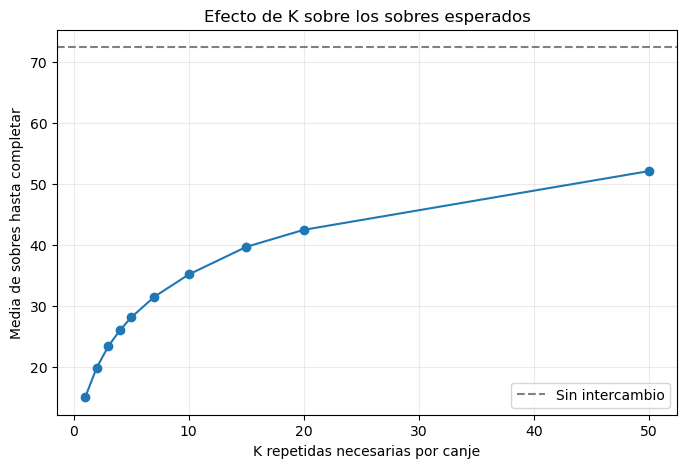

In [9]:
K_EXTRA = [1, 2, 3, 4, 5, 7, 10, 15, 20, 50]
rng_extra = np.random.default_rng(SEMILLA)

medias_extra = []
for k in K_EXTRA:
    datos = simular_hasta_completar_lote(N, S, R, k, rng_extra)
    medias_extra.append(datos.mean())

print(f"{'K':>5} | {'Media sobres':>13} | {'Reducción':>10}")
print("-" * 36)
for k, media in zip(K_EXTRA, medias_extra):
    reduccion = (media_sin_intercambio - media) / media_sin_intercambio * 100
    print(f"{k:5d} | {media:13.3f} | {reduccion:9.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(K_EXTRA, medias_extra, marker="o")
plt.axhline(media_sin_intercambio, color="gray", linestyle="--", label="Sin intercambio")
plt.xlabel("K repetidas necesarias por canje")
plt.ylabel("Media de sobres hasta completar")
plt.title("Efecto de K sobre los sobres esperados")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## Preguntas de análisis

**1. ¿Cómo afecta la disminución de K al número esperado de sobres y a la probabilidad de éxito? ¿Es lineal la relación?**

Al disminuir `K`, el intercambio se vuelve más favorable: se necesitan menos repetidas para obtener una estampa nueva. Por eso baja mucho el número esperado de sobres y sube la probabilidad de completar para un mismo `M`. La relación no es lineal. Pasar de no tener intercambio a `K=10` ya reduce la media de `72.472` a `35.157` sobres, mientras que mejoras posteriores tienen efectos distintos según la zona: `K=5` baja a `28.096`, `K=2` a `19.867` y `K=1` llega al mínimo práctico de `15` sobres.

**2. Para K = 2, ¿cuántos sobres se ahorran en promedio respecto al caso sin intercambio? ¿Cuál es el ahorro en quetzales?**

Sin intercambio la media fue `72.472` sobres y con `K=2` fue `19.867`. El ahorro promedio es `72.472 - 19.867 = 52.605` sobres. A Q9.50 por sobre, el ahorro esperado es aproximadamente `52.605 × 9.50 = Q499.75`.

**3. Para M = 45, ¿cuánto aumenta la probabilidad al pasar de K = 10 a K = 5, y de K = 5 a K = 1?**

Para `M = 45`, las tres probabilidades son `1.0000` para `K=10`, `K=5` y `K=1`. Por lo tanto, el aumento observado es `0.0000` al pasar de `K=10` a `K=5`, y también `0.0000` al pasar de `K=5` a `K=1`. En este punto el álbum ya está prácticamente garantizado con cualquier tasa de intercambio de la lista. Si se mira un valor más informativo como `M=30`, la probabilidad pasa de `0.0304` con `K=10` a `0.9515` con `K=5`, y luego a `1.0000` con `K=1`.

**4. ¿Existe un valor de K a partir del cual mejorar la tasa produce poco beneficio adicional?**

La exploración adicional sugiere rendimientos decrecientes cuando `K` ya es pequeño. Por ejemplo, pasar de `K=2` a `K=1` mejora la media de unos `19.9` sobres a `15`, pero `15` es el mínimo posible porque con 14 sobres solo se obtienen 98 estampas. Una razón es que, al acercarse al mínimo teórico `ceil(100/7)=15`, ya casi no queda espacio para seguir reduciendo sobres. En cambio, para valores grandes de `K`, el intercambio ayuda menos porque se acumulan canjes demasiado lentamente.

**5. ¿Cuál es el costo efectivo por estampa nueva obtenida mediante canje? ¿Qué tasa K sería más rentable?**

Cada sobre cuesta Q9.50 y trae 7 estampas, así que el costo pagado por estampa es `9.50/7 ≈ Q1.36`. Si se atribuye ese costo a las repetidas usadas en el canje, una estampa nueva obtenida por intercambio cuesta efectivamente `K × 9.50/7`. Entonces: `K=1` cuesta Q1.36, `K=2` cuesta Q2.71, `K=5` cuesta Q6.79 y `K=10` cuesta Q13.57 por estampa canjeada. Si se pudiera elegir libremente, `K=1` sería la tasa más rentable. Si se considera que las repetidas ya fueron pagadas de todos modos, el costo marginal del canje es Q0, pero `K=1` sigue siendo la opción dominante porque aprovecha mejor las repetidas.
